In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q lightgbm catboost transformers sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:


# ============================
# 3. IMPORTS
# ============================
import os
import re
import gc
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from transformers import AutoTokenizer, AutoModel

In [ ]:
# ============================
# 4. CONFIGURATION
# ============================
FILE_PATH = '/content/drive/MyDrive/DL_Project_Code/Clinical/PCOS_data_2.xlsx'
SAVE_DIR = '/content/drive/MyDrive/DL_Project_Code/Clinical/final_compare_models_improved'
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_COL = 'PCOS (Y/N)'
DROP_COLS = ['Unnamed: 44']

# Stronger clinical/domain transformers
TRANSFORMER_MODELS = [
    "bert-base-uncased",
    "emilyalsentzer/Bio_ClinicalBERT",
    "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
    "dmis-lab/biobert-base-cased-v1.2"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# ============================
# 5. LOAD DATA
# ============================
df = pd.read_excel(FILE_PATH)
print("Original shape:", df.shape)

for col in DROP_COLS:
    if col in df.columns:
        df = df.drop(columns=[col])

if 'Marraige Status (Yrs)' in df.columns:
    df['Marraige Status (Yrs)'].fillna(df['Marraige Status (Yrs)'].mode()[0], inplace=True)

if 'Fast food (Y/N)' in df.columns:
    df['Fast food (Y/N)'].fillna(df['Fast food (Y/N)'].mode()[0], inplace=True)

for col in df.columns:
    if col != TARGET_COL:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

feature_columns = X.columns.tolist()
print("Number of features:", len(feature_columns))

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

print("X_train samples:", len(X_train_df))
print("X_test samples:", len(X_test_df))
print("y_train samples:", len(y_train))
print("y_test samples:", len(y_test))

Original shape: (541, 45)
Shape after cleaning: (541, 44)
Number of features: 43
X_train samples: 432
X_test samples: 109
y_train samples: 432
y_test samples: 109


In [ ]:
# ============================
# 6. IMPUTE MISSING VALUES
# ============================
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

joblib.dump(imputer, os.path.join(SAVE_DIR, 'imputer.pkl'))
joblib.dump(feature_columns, os.path.join(SAVE_DIR, 'feature_columns.pkl'))

['/content/drive/MyDrive/DL_Project_Code/Clinical/final_compare_models_improved/feature_columns.pkl']

In [ ]:
# ============================
# 7. HELPERS
# ============================
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

def print_metrics(model_name, y_true, y_pred):
    print(f"\n=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

def sanitize_columns(df_input):
    df_copy = df_input.copy()
    new_cols = []
    for col in df_copy.columns:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', str(col))
        new_col = new_col.replace(' ', '_')
        new_cols.append(new_col)
    df_copy.columns = new_cols
    return df_copy

In [ ]:
# ============================
# 8. BASELINE ML MODELS
# ============================
baseline_results = []

scaler_raw = StandardScaler()
X_train_scaled = scaler_raw.fit_transform(X_train_imp)
X_test_scaled = scaler_raw.transform(X_test_imp)

joblib.dump(scaler_raw, os.path.join(SAVE_DIR, 'raw_feature_scaler.pkl'))

# Logistic Regression
logreg = LogisticRegression(max_iter=10000, random_state=1)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print_metrics("Baseline Logistic Regression", y_test, y_pred_logreg)
m = compute_metrics(y_test, y_pred_logreg)
baseline_results.append(["Baseline", "Raw Features", "Logistic Regression", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# KNN with best k
best_acc = -1
best_k = 1
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn_temp.fit(X_train_scaled, y_train)
    pred_temp = knn_temp.predict(X_test_scaled)
    acc_temp = accuracy_score(y_test, pred_temp)
    if acc_temp > best_acc:
        best_acc = acc_temp
        best_k = k

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print(f"\nBest k for KNN: {best_k}")
print_metrics("Baseline KNN", y_test, y_pred_knn)
m = compute_metrics(y_test, y_pred_knn)
baseline_results.append(["Baseline", "Raw Features", f"KNN (k={best_k})", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# Naive Bayes
nb = GaussianNB(var_smoothing=1e-2)
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print_metrics("Baseline Naive Bayes", y_test, y_pred_nb)
m = compute_metrics(y_test, y_pred_nb)
baseline_results.append(["Baseline", "Raw Features", "Naive Bayes", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# SVM
svm_model = svm.SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=1)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print_metrics("Baseline SVM", y_test, y_pred_svm)
m = compute_metrics(y_test, y_pred_svm)
baseline_results.append(["Baseline", "Raw Features", "SVM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# Decision Tree - Gini
dt_gini = DecisionTreeClassifier(random_state=1)
dt_gini.fit(X_train_imp, y_train)
y_pred_dt_gini = dt_gini.predict(X_test_imp)
print_metrics("Baseline Decision Tree (Gini)", y_test, y_pred_dt_gini)
m = compute_metrics(y_test, y_pred_dt_gini)
baseline_results.append(["Baseline", "Raw Features", "Decision Tree (Gini)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# Decision Tree - Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt_entropy.fit(X_train_imp, y_train)
y_pred_dt_entropy = dt_entropy.predict(X_test_imp)
print_metrics("Baseline Decision Tree (Entropy)", y_test, y_pred_dt_entropy)
m = compute_metrics(y_test, y_pred_dt_entropy)
baseline_results.append(["Baseline", "Raw Features", "Decision Tree (Entropy)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train_imp, y_train)
y_pred_rf = rf.predict(X_test_imp)
print_metrics("Baseline Random Forest", y_test, y_pred_rf)
m = compute_metrics(y_test, y_pred_rf)
baseline_results.append(["Baseline", "Raw Features", "Random Forest", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# LightGBM
X_train_lgbm = sanitize_columns(X_train_imp)
X_test_lgbm = sanitize_columns(X_test_imp)

lgbm = LGBMClassifier(
    learning_rate=0.1,
    verbosity=-1,
    random_state=1
)
lgbm.fit(X_train_lgbm, y_train)
y_pred_lgbm = lgbm.predict(X_test_lgbm)
print_metrics("Baseline LightGBM", y_test, y_pred_lgbm)
m = compute_metrics(y_test, y_pred_lgbm)
baseline_results.append(["Baseline", "Raw Features", "LightGBM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# AdaBoost
ada = AdaBoostClassifier(random_state=1)
ada.fit(X_train_imp, y_train)
y_pred_ada = ada.predict(X_test_imp)
print_metrics("Baseline AdaBoost", y_test, y_pred_ada)
m = compute_metrics(y_test, y_pred_ada)
baseline_results.append(["Baseline", "Raw Features", "AdaBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# CatBoost
cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    random_seed=1,
    eval_metric='Accuracy',
    use_best_model=True,
    od_type='Iter',
    od_wait=40,
    verbose=False
)
cat.fit(X_train_imp, y_train, eval_set=(X_test_imp, y_test))
y_pred_cat = cat.predict(X_test_imp)
y_pred_cat = np.array(y_pred_cat).astype(int).reshape(-1)
print_metrics("Baseline CatBoost", y_test, y_pred_cat)
m = compute_metrics(y_test, y_pred_cat)
baseline_results.append(["Baseline", "Raw Features", "CatBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=1
)
xgb_model.fit(X_train_imp, y_train)
y_pred_xgb = xgb_model.predict(X_test_imp)
print_metrics("Baseline XGBoost", y_test, y_pred_xgb)
m = compute_metrics(y_test, y_pred_xgb)
baseline_results.append(["Baseline", "Raw Features", "XGBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# save baseline models
joblib.dump(logreg, os.path.join(SAVE_DIR, 'baseline_logreg.pkl'))
joblib.dump(knn, os.path.join(SAVE_DIR, 'baseline_knn.pkl'))
joblib.dump(nb, os.path.join(SAVE_DIR, 'baseline_nb.pkl'))
joblib.dump(svm_model, os.path.join(SAVE_DIR, 'baseline_svm.pkl'))
joblib.dump(dt_gini, os.path.join(SAVE_DIR, 'baseline_dt_gini.pkl'))
joblib.dump(dt_entropy, os.path.join(SAVE_DIR, 'baseline_dt_entropy.pkl'))
joblib.dump(rf, os.path.join(SAVE_DIR, 'baseline_rf.pkl'))
joblib.dump(lgbm, os.path.join(SAVE_DIR, 'baseline_lgbm.pkl'))
joblib.dump(ada, os.path.join(SAVE_DIR, 'baseline_ada.pkl'))
joblib.dump(cat, os.path.join(SAVE_DIR, 'baseline_catboost.pkl'))
joblib.dump(xgb_model, os.path.join(SAVE_DIR, 'baseline_xgb.pkl'))


=== Baseline Logistic Regression ===
Confusion Matrix:
[[68  5]
 [ 2 34]]
Accuracy : 0.9358
Precision: 0.8718
Recall   : 0.9444
F1-score : 0.9067

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        73
           1       0.87      0.94      0.91        36

    accuracy                           0.94       109
   macro avg       0.92      0.94      0.93       109
weighted avg       0.94      0.94      0.94       109


Best k for KNN: 10

=== Baseline KNN ===
Confusion Matrix:
[[72  1]
 [10 26]]
Accuracy : 0.8991
Precision: 0.9630
Recall   : 0.7222
F1-score : 0.8254

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        73
           1       0.96      0.72      0.83        36

    accuracy                           0.90       109
   macro avg       0.92      0.85      0.88       109
weighted avg       0.91      0.90      0.89       109



['/content/drive/MyDrive/DL_Project_Code/Clinical/final_compare_models_improved/baseline_xgb.pkl']

In [ ]:
# ============================
# 9. IMPROVED CLINICAL TEXT
# ============================
def clean_feature_name(col):
    col = str(col)
    col = col.replace("(Y/N)", "")
    col = col.replace("(yrs)", "years")
    col = col.replace("(Kg)", "kg")
    col = col.replace("(Cm)", "cm")
    col = col.replace("(bpm)", "bpm")
    col = col.replace("(mmHg)", "mmHg")
    col = col.replace("(R/I)", "regularity")
    col = col.replace("/", " per ")
    col = col.replace("  ", " ")
    col = re.sub(r'[\(\)]', '', col)
    col = re.sub(r'[_]+', ' ', col)
    return col.strip()

binary_hint_keywords = [
    'Y/N', 'pregnant', 'Weight gain', 'hair growth',
    'Skin darkening', 'Pimples', 'Fast food', 'Reg.Exercise'
]

def format_value(col, val):
    col_str = str(col)

    if pd.isna(val):
        return "unknown"

    if col_str == 'Cycle(R/I)':
        if val == 4:
            return "irregular"
        elif val == 2:
            return "regular"
        return str(val)

    if any(k in col_str for k in binary_hint_keywords):
        if val == 1:
            return "yes"
        elif val == 0:
            return "no"
        return str(val)

    if isinstance(val, (int, np.integer)):
        return str(int(val))

    if isinstance(val, (float, np.floating)):
        if float(val).is_integer():
            return str(int(val))
        return f"{val:.2f}"

    return str(val)

def row_to_structured_clinical_text(row):
    sections = []

    demo_fields = [
        ' Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group'
    ]
    demo_text = []
    for col in demo_fields:
        if col in row.index:
            demo_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if demo_text:
        sections.append("Demographics: " + "; ".join(demo_text) + ".")

    cycle_fields = [
        'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
        'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
        'Pregnant(Y/N)', 'No. of aborptions'
    ]
    cycle_text = []
    for col in cycle_fields:
        if col in row.index:
            if col == 'Cycle(R/I)':
                cycle_text.append(f"Cycle pattern: {format_value(col, row[col])}")
            else:
                cycle_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if cycle_text:
        sections.append("Menstrual and general history: " + "; ".join(cycle_text) + ".")

    symptom_fields = [
        'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
        'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)'
    ]
    symptom_text = []
    for col in symptom_fields:
        if col in row.index:
            symptom_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if symptom_text:
        sections.append("Symptoms and lifestyle: " + "; ".join(symptom_text) + ".")

    hormone_fields = [
        'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)',
        'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
        'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'I   beta-HCG(mIU/mL)',
        'II    beta-HCG(mIU/mL)'
    ]
    hormone_text = []
    for col in hormone_fields:
        if col in row.index:
            hormone_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if hormone_text:
        sections.append("Hormonal and biochemical profile: " + "; ".join(hormone_text) + ".")

    usg_fields = [
        'Follicle No. (L)', 'Follicle No. (R)',
        'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
        'Endometrium (mm)'
    ]
    usg_text = []
    for col in usg_fields:
        if col in row.index:
            usg_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if usg_text:
        sections.append("Ultrasound-related indicators: " + "; ".join(usg_text) + ".")

    used_cols = set(demo_fields + cycle_fields + symptom_fields + hormone_fields + usg_fields)
    remaining_cols = [c for c in row.index if c not in used_cols]
    other_text = []
    for col in remaining_cols:
        other_text.append(f"{clean_feature_name(col)}: {format_value(col, row[col])}")
    if other_text:
        sections.append("Other clinical features: " + "; ".join(other_text) + ".")

    final_text = "Patient clinical profile. " + " ".join(sections)
    return final_text

train_texts = X_train_imp.apply(row_to_structured_clinical_text, axis=1).tolist()
test_texts = X_test_imp.apply(row_to_structured_clinical_text, axis=1).tolist()

print("\nSample improved clinical narrative:\n")
print(train_texts[0][:2000])


Sample improved clinical narrative:

Patient clinical profile. Demographics: Weight kg: 60; Heightcm: 156; BMI: 24.70; Blood Group: 13. Menstrual and general history: Pulse ratebpm: 74; RR breaths per min: 18; Hbg per dl: 11.20; Cycle pattern: irregular; Cycle lengthdays: 4; Marraige Status Yrs: 8; Pregnant: no. Symptoms and lifestyle: Weight gain: yes; hair growth: yes; Skin darkening: no; Hair loss: yes; Pimples: yes; Fast food: yes; Reg.Exercise: no. Hormonal and biochemical profile: FSHmIU per mL: 5.43; LHmIU per mL: 6.82; FSH per LH: 0.80; Hipinch: 42; Waistinch: 36; Waist:Hip Ratio: 0.86; TSH mIU per L: 3.55; AMHng per mL: 3.65; PRLng per mL: 16.41; Vit D3 ng per mL: 26.60; PRGng per mL: 0.12; RBSmg per dl: 91; I  beta-HCGmIU per mL: 1.99; II  beta-HCGmIU per mL: 1.99. Ultrasound-related indicators: Follicle No. L: 13; Follicle No. R: 12; Avg. F size L mm: 15; Avg. F size R mm: 16; Endometrium mm: 8.50. Other clinical features: Sl. No: 172; Patient File No.: 172; Age years: 29; 

In [ ]:
# ============================
# 10. TRANSFORMER EMBEDDINGS
# ============================
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)

def extract_transformer_embeddings(texts, model_name, batch_size=8, max_length=256):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding {model_name.split('/')[-1]}"):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        batch_embeddings = mean_pooling(outputs, inputs["attention_mask"]).cpu().numpy()
        all_embeddings.append(batch_embeddings)

    embeddings = np.vstack(all_embeddings)

    del tokenizer
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return embeddings

In [ ]:
# ============================
# 11. ML MODELS ON TRANSFORMER EMBEDDINGS
# ============================f
transformer_results = []

for transformer_name in TRANSFORMER_MODELS:
    print("\n" + "=" * 90)
    print(f"TRANSFORMER: {transformer_name}")
    print("=" * 90)

    X_train_emb = extract_transformer_embeddings(train_texts, transformer_name)
    X_test_emb = extract_transformer_embeddings(test_texts, transformer_name)

    emb_scaler = StandardScaler()
    X_train_emb_scaled = emb_scaler.fit_transform(X_train_emb)
    X_test_emb_scaled = emb_scaler.transform(X_test_emb)

    pca = PCA(n_components=min(128, X_train_emb_scaled.shape[1]), random_state=1)
    X_train_emb_pca = pca.fit_transform(X_train_emb_scaled)
    X_test_emb_pca = pca.transform(X_test_emb_scaled)

    print(f"PCA reduced embedding dimension from {X_train_emb.shape[1]} to {X_train_emb_pca.shape[1]}")

    # Logistic Regression
    logreg_t = LogisticRegression(
        max_iter=20000,
        random_state=1,
        C=1.0,
        class_weight='balanced'
    )
    logreg_t.fit(X_train_emb_pca, y_train)
    y_pred = logreg_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + Logistic Regression", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "Logistic Regression", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # KNN
    best_acc = -1
    best_k = 1
    for k in range(3, 16, 2):
        knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
        knn_temp.fit(X_train_emb_pca, y_train)
        pred_temp = knn_temp.predict(X_test_emb_pca)
        acc_temp = accuracy_score(y_test, pred_temp)
        if acc_temp > best_acc:
            best_acc = acc_temp
            best_k = k

    knn_t = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
    knn_t.fit(X_train_emb_pca, y_train)
    y_pred = knn_t.predict(X_test_emb_pca)
    print(f"\nBest k on embeddings for {transformer_name.split('/')[-1]}: {best_k}")
    print_metrics(f"{transformer_name.split('/')[-1]} + KNN", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], f"KNN (k={best_k})", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # Naive Bayes
    nb_t = GaussianNB(var_smoothing=1e-1)
    nb_t.fit(X_train_emb_pca, y_train)
    y_pred = nb_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + Naive Bayes", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "Naive Bayes", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # SVM
    svm_t = svm.SVC(
        kernel='rbf',
        C=2.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=1
    )
    svm_t.fit(X_train_emb_pca, y_train)
    y_pred = svm_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + SVM", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "SVM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # Decision Tree - Gini
    dt_gini_t = DecisionTreeClassifier(max_depth=6, random_state=1)
    dt_gini_t.fit(X_train_emb_pca, y_train)
    y_pred = dt_gini_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + Decision Tree (Gini)", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "Decision Tree (Gini)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # Decision Tree - Entropy
    dt_entropy_t = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=1)
    dt_entropy_t.fit(X_train_emb_pca, y_train)
    y_pred = dt_entropy_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + Decision Tree (Entropy)", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "Decision Tree (Entropy)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # Random Forest
    rf_t = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=1
    )
    rf_t.fit(X_train_emb_pca, y_train)
    y_pred = rf_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + Random Forest", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "Random Forest", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # LightGBM
    X_train_emb_df = pd.DataFrame(X_train_emb_pca, columns=[f"emb_{i}" for i in range(X_train_emb_pca.shape[1])])
    X_test_emb_df = pd.DataFrame(X_test_emb_pca, columns=[f"emb_{i}" for i in range(X_test_emb_pca.shape[1])])

    lgbm_t = LGBMClassifier(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=6,
        verbosity=-1,
        random_state=1
    )
    lgbm_t.fit(X_train_emb_df, y_train)
    y_pred = lgbm_t.predict(X_test_emb_df)
    print_metrics(f"{transformer_name.split('/')[-1]} + LightGBM", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "LightGBM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # AdaBoost
    ada_t = AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=1
    )
    ada_t.fit(X_train_emb_pca, y_train)
    y_pred = ada_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + AdaBoost", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "AdaBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # CatBoost
    cat_t = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=5,
        random_seed=1,
        eval_metric='Accuracy',
        verbose=False
    )
    cat_t.fit(X_train_emb_df, y_train, eval_set=(X_test_emb_df, y_test))
    y_pred = cat_t.predict(X_test_emb_df)
    y_pred = np.array(y_pred).astype(int).reshape(-1)
    print_metrics(f"{transformer_name.split('/')[-1]} + CatBoost", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "CatBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # XGBoost
    xgb_t = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric='logloss',
        random_state=1
    )
    xgb_t.fit(X_train_emb_pca, y_train)
    y_pred = xgb_t.predict(X_test_emb_pca)
    print_metrics(f"{transformer_name.split('/')[-1]} + XGBoost", y_test, y_pred)
    m = compute_metrics(y_test, y_pred)
    transformer_results.append(["Transformer", transformer_name.split('/')[-1], "XGBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

    # Save important models
    base_name = transformer_name.split('/')[-1]
    joblib.dump(logreg_t, os.path.join(SAVE_DIR, f'{base_name}_logreg.pkl'))
    joblib.dump(svm_t, os.path.join(SAVE_DIR, f'{base_name}_svm.pkl'))
    joblib.dump(rf_t, os.path.join(SAVE_DIR, f'{base_name}_rf.pkl'))
    joblib.dump(cat_t, os.path.join(SAVE_DIR, f'{base_name}_catboost.pkl'))
    joblib.dump(xgb_t, os.path.join(SAVE_DIR, f'{base_name}_xgb.pkl'))
    joblib.dump(emb_scaler, os.path.join(SAVE_DIR, f'{base_name}_embedding_scaler.pkl'))
    joblib.dump(pca, os.path.join(SAVE_DIR, f'{base_name}_pca.pkl'))


TRANSFORMER: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Embedding biobert-base-cased-v1.2: 100%|██████████| 54/54 [00:06<00:00,  7.97it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding biobert-base-cased-v1.2: 100%|██████████| 14/14 [00:01<00:00,  8.28it/s]


PCA reduced embedding dimension from 768 to 128

=== biobert-base-cased-v1.2 + Logistic Regression ===
Confusion Matrix:
[[59 14]
 [13 23]]
Accuracy : 0.7523
Precision: 0.6216
Recall   : 0.6389
F1-score : 0.6301

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        73
           1       0.62      0.64      0.63        36

    accuracy                           0.75       109
   macro avg       0.72      0.72      0.72       109
weighted avg       0.75      0.75      0.75       109


Best k on embeddings for biobert-base-cased-v1.2: 13

=== biobert-base-cased-v1.2 + KNN ===
Confusion Matrix:
[[68  5]
 [19 17]]
Accuracy : 0.7798
Precision: 0.7727
Recall   : 0.4722
F1-score : 0.5862

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85        73
           1       0.77      0.47      0.59        36

    accuracy                           0.78    

In [ ]:
# ============================
# 12. COMBINE RESULTS
# ============================
baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Type", "Representation", "Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

transformer_df = pd.DataFrame(
    transformer_results,
    columns=["Type", "Representation", "Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

all_results_df = pd.concat([baseline_df, transformer_df], ignore_index=True)
all_results_df = all_results_df.round(4)

print("\n" + "=" * 120)
print("FINAL COMPARISON TABLE")
print("=" * 120)
print(all_results_df.to_string(index=False))

all_results_path = os.path.join(SAVE_DIR, "baseline_vs_transformer_results.csv")
all_results_df.to_csv(all_results_path, index=False)
print(f"\nSaved final results to: {all_results_path}")


FINAL COMPARISON TABLE
       Type                                      Representation                   Model  Accuracy  Precision  Recall  F1-score
   Baseline                                        Raw Features     Logistic Regression   93.5780     0.8718  0.9444    0.9067
   Baseline                                        Raw Features              KNN (k=10)   89.9083     0.9630  0.7222    0.8254
   Baseline                                        Raw Features             Naive Bayes   88.0734     0.7805  0.8889    0.8312
   Baseline                                        Raw Features                     SVM   91.7431     0.9091  0.8333    0.8696
   Baseline                                        Raw Features    Decision Tree (Gini)   81.6514     0.7500  0.6667    0.7059
   Baseline                                        Raw Features Decision Tree (Entropy)   81.6514     0.7353  0.6944    0.7143
   Baseline                                        Raw Features           Random Forest

In [ ]:

baseline_only = baseline_df[["Model", "Accuracy", "Precision", "Recall", "F1-score"]].copy()
baseline_only.columns = ["Model", "Baseline Accuracy", "Baseline Precision", "Baseline Recall", "Baseline F1-score"]

comparison_rows = []

for _, b_row in baseline_only.iterrows():
    model_name = b_row["Model"]
    matching_transformers = transformer_df[transformer_df["Model"] == model_name]

    for _, t_row in matching_transformers.iterrows():
        comparison_rows.append([
            model_name,
            b_row["Baseline Accuracy"],
            t_row["Representation"],
            t_row["Accuracy"],
            t_row["Precision"],
            t_row["Recall"],
            t_row["F1-score"],
            t_row["Accuracy"] - b_row["Baseline Accuracy"]
        ])

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=[
        "Model",
        "Baseline Accuracy",
        "Transformer Model",
        "Transformer Accuracy",
        "Transformer Precision",
        "Transformer Recall",
        "Transformer F1-score",
        "Accuracy Gain/Loss"
    ]
)

comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values(by=["Model", "Transformer Accuracy"], ascending=[True, False]).reset_index(drop=True)

print("\n" + "=" * 120)
print("MODEL-WISE BEFORE vs AFTER TRANSFORMER COMPARISON")
print("=" * 120)
print(comparison_df.to_string(index=False))

comparison_path = os.path.join(SAVE_DIR, "modelwise_baseline_vs_transformer.csv")
comparison_df.to_csv(comparison_path, index=False)


MODEL-WISE BEFORE vs AFTER TRANSFORMER COMPARISON
                  Model  Baseline Accuracy                                   Transformer Model  Transformer Accuracy  Transformer Precision  Transformer Recall  Transformer F1-score  Accuracy Gain/Loss
               AdaBoost            93.5780                                    Bio_ClinicalBERT               81.6514                 0.8333              0.5556                0.6667            -11.9266
               AdaBoost            93.5780                                   bert-base-uncased               79.8165                 0.7917              0.5278                0.6333            -13.7615
               AdaBoost            93.5780                             biobert-base-cased-v1.2               77.9817                 0.7727              0.4722                0.5862            -15.5963
               AdaBoost            93.5780 BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext               75.2294                 0.6800  

In [ ]:

best_per_transformer = (
    transformer_df.sort_values(by=["F1-score", "Accuracy"], ascending=[False, False])
    .groupby("Representation")
    .first()
    .reset_index()
)

print("\n" + "=" * 120)
print("BEST CLASSIFIER RESULT FOR EACH TRANSFORMER")
print("=" * 120)
print(best_per_transformer.to_string(index=False))

best_transformer_path = os.path.join(SAVE_DIR, "best_per_transformer.csv")
best_per_transformer.to_csv(best_transformer_path, index=False)


BEST CLASSIFIER RESULT FOR EACH TRANSFORMER
                                     Representation        Type    Model  Accuracy  Precision   Recall  F1-score
                                   Bio_ClinicalBERT Transformer LightGBM 86.238532   0.862069 0.694444  0.769231
BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext Transformer      SVM 83.486239   0.781250 0.694444  0.735294
                                  bert-base-uncased Transformer CatBoost 83.486239   0.846154 0.611111  0.709677
                            biobert-base-cased-v1.2 Transformer CatBoost 83.486239   0.846154 0.611111  0.709677


In [ ]:
display(baseline_df)

,Type,Representation,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,Raw Features,Logistic Regression,93.577982,0.871795,0.944444,0.906667
1,Baseline,Raw Features,KNN (k=10),89.908257,0.962963,0.722222,0.825397
2,Baseline,Raw Features,Naive Bayes,88.073394,0.780488,0.888889,0.831169
3,Baseline,Raw Features,SVM,91.743119,0.909091,0.833333,0.869565
4,Baseline,Raw Features,Decision Tree (Gini),81.651376,0.750000,0.666667,0.705882
5,Baseline,Raw Features,Decision Tree (Entropy),81.651376,0.735294,0.694444,0.714286
6,Baseline,Raw Features,Random Forest,91.743119,0.935484,0.805556,0.865672
7,Baseline,Raw Features,LightGBM,94.495413,0.916667,0.916667,0.916667
8,Baseline,Raw Features,AdaBoost,93.577982,0.939394,0.861111,0.898551
9,Baseline,Raw Features,CatBoost,95.412844,0.942857,0.916667,0.929577


In [ ]:
display(transformer_df)

,Type,Representation,Model,Accuracy,Precision,Recall,F1-score
0,Transformer,bert-base-uncased,Logistic Regression,78.899083,0.696970,0.638889,0.666667
1,Transformer,bert-base-uncased,KNN (k=9),79.816514,0.888889,0.444444,0.592593
2,Transformer,bert-base-uncased,Naive Bayes,73.394495,0.818182,0.250000,0.382979
3,Transformer,bert-base-uncased,SVM,79.816514,0.718750,0.638889,0.676471
4,Transformer,bert-base-uncased,Decision Tree (Gini),74.311927,0.642857,0.500000,0.562500
5,Transformer,bert-base-uncased,Decision Tree (Entropy),78.899083,0.685714,0.666667,0.676056
6,Transformer,bert-base-uncased,Random Forest,73.394495,0.888889,0.222222,0.355556
7,Transformer,bert-base-uncased,LightGBM,80.733945,0.777778,0.583333,0.666667
8,Transformer,bert-base-uncased,AdaBoost,79.816514,0.791667,0.527778,0.633333
9,Transformer,bert-base-uncased,CatBoost,83.486239,0.846154,0.611111,0.709677


In [ ]:
display(comparison_df)

,Model,Baseline Accuracy,Transformer Model,Transformer Accuracy,Transformer Precision,Transformer Recall,Transformer F1-score,Accuracy Gain/Loss
0,AdaBoost,93.5780,Bio_ClinicalBERT,81.6514,0.8333,0.5556,0.6667,-11.9266
1,AdaBoost,93.5780,bert-base-uncased,79.8165,0.7917,0.5278,0.6333,-13.7615
2,AdaBoost,93.5780,biobert-base-cased-v1.2,77.9817,0.7727,0.4722,0.5862,-15.5963
3,AdaBoost,93.5780,BiomedNLP-PubMedBERT-base-uncased-abstract-ful...,75.2294,0.6800,0.4722,0.5574,-18.3486
4,CatBoost,95.4128,Bio_ClinicalBERT,84.4037,0.8519,0.6389,0.7302,-11.0092
5,CatBoost,95.4128,bert-base-uncased,83.4862,0.8462,0.6111,0.7097,-11.9266
6,CatBoost,95.4128,biobert-base-cased-v1.2,83.4862,0.8462,0.6111,0.7097,-11.9266
7,CatBoost,95.4128,BiomedNLP-PubMedBERT-base-uncased-abstract-ful...,77.9817,0.8000,0.4444,0.5714,-17.4312
8,Decision Tree (Entropy),81.6514,bert-base-uncased,78.8991,0.6857,0.6667,0.6761,-2.7523
9,Decision Tree (Entropy),81.6514,Bio_ClinicalBERT,76.1468,0.6389,0.6389,0.6389,-5.5046


In [ ]:
display(best_per_transformer)

,Representation,Type,Model,Accuracy,Precision,Recall,F1-score
0,Bio_ClinicalBERT,Transformer,LightGBM,86.238532,0.862069,0.694444,0.769231
1,BiomedNLP-PubMedBERT-base-uncased-abstract-ful...,Transformer,SVM,83.486239,0.781250,0.694444,0.735294
2,bert-base-uncased,Transformer,CatBoost,83.486239,0.846154,0.611111,0.709677
3,biobert-base-cased-v1.2,Transformer,CatBoost,83.486239,0.846154,0.611111,0.709677


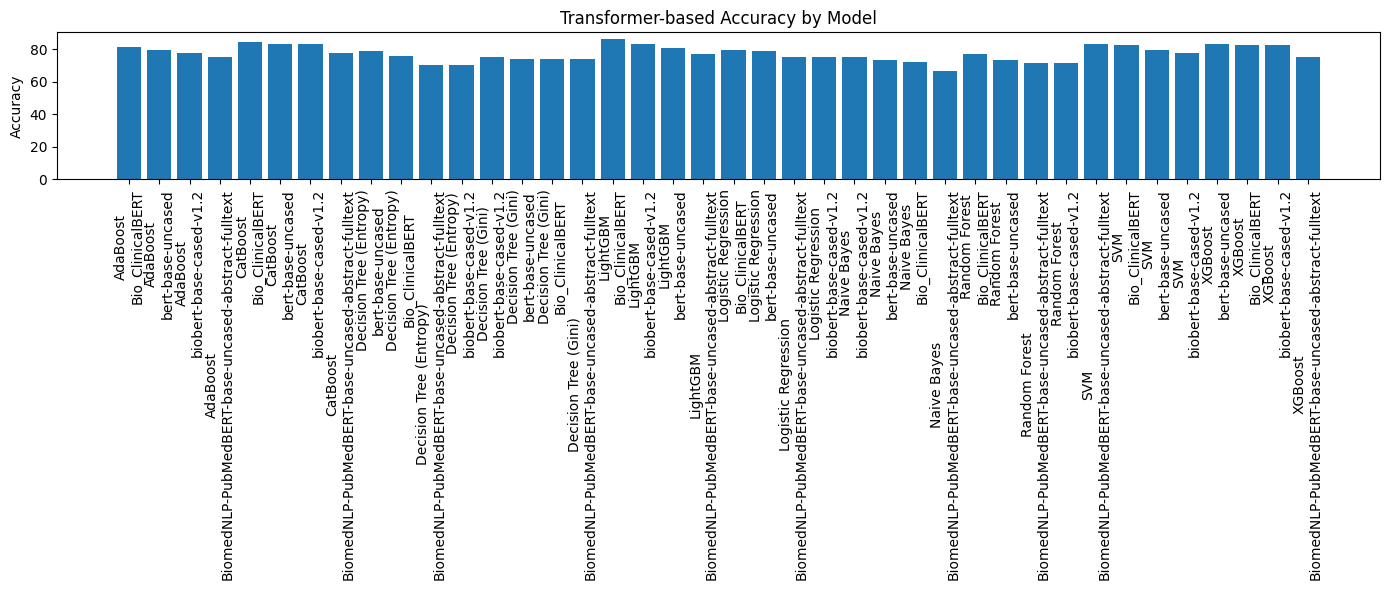

In [ ]:

top_plot_df = comparison_df.copy()

plt.figure(figsize=(14, 6))
plt.bar(
    [f"{row['Model']}\n{row['Transformer Model']}" for _, row in top_plot_df.iterrows()],
    top_plot_df["Transformer Accuracy"]
)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Transformer-based Accuracy by Model")
plt.tight_layout()
plt.show()